# Song Recognition from Humming and Whistling Using Audio Feature Classification

**Author:** Pavel Trofimchik  
**Context:** Machine Learning coursework project, MSc Data Science & AI, Queen Mary University of London (2025–26)  
**Repository:** [github.com/TrPavel/query-by-humming-classification](https://github.com/TrPavel/query-by-humming-classification)

## Problem Formulation

This project tackles a **multiclass audio classification task**: given a 10-second recording of a person humming or whistling, the goal is to predict which of eight target songs they are trying to reproduce. This setup is closely related to classic *query-by-humming* (QbH) and *query-by-singing* systems, where a short vocal query is matched to a song in a database (Pauws, 2002; Nagavi & Bhajantri, 2013).

**Input.** A 10-second WAV recording (22,050 Hz) containing a human interpretation (humming or whistling) of a song fragment.  
**Output.** One of eight song labels: *Happy*, *TryEverything*, *RememberMe*, *NewYork*, *Friend*, *Necessities*, *Feeling*, or *Married*.

### Challenges

Several aspects make this task more difficult than standard audio classification:

1. **High inter-performer variability.**  
   Different people sing the same melody with different pitch, tempo and rhythmic accuracy. Prior QbH research shows that users often shift key, add or remove notes, or distort melodic intervals, even though the general contour is preserved (Pauws, 2002). Such inconsistencies make it difficult for a model to learn song-invariant features.

2. **No linguistic content.**  
   Humming and whistling contain no words, unlike speech recognition or lyric-based music retrieval. The model must rely purely on melodic and spectral cues such as pitch trajectory, timbre and rhythm. Traditional QbH systems similarly depend on melodic descriptors such as MFCCs, LPC or pitch contours (Nagavi & Bhajantri, 2013; Patel, 2019).

3. **Limited training data.**  
   The dataset contains roughly 100 samples per class, which is small for learning robust melodic representations. Modern QbH systems typically rely on large collections of queries and cover recordings—often many hours of audio—to train neural embedding models (Amatov et al., 2023; Pham et al., 2024). With limited data, classical machine-learning methods can perform as well as or better than deep learning.

4. **Two vocalisation modes (humming and whistling).**  
   Although both represent the same melody, humming and whistling differ strongly in timbre, harmonic structure and frequency distribution. A single classifier must therefore learn to ignore these modality differences and focus on the underlying melodic pattern.

Overall, this is a supervised multiclass classification problem. A key requirement is that the model should **generalise to new singers not seen during training**, which mirrors practical QbH systems where user queries come from previously unseen performerication or QbH system. 


## Methodology

### Training and Validation Strategy

The dataset contains 800 audio files from 187 interpreters. To obtain an honest estimate of generalisation, I use **GroupShuffleSplit** based on interpreter ID. All recordings from a single person are placed either in the training set or in the validation set, but never split across both.

This follows best practice in QbH evaluation: splitting by performer prevents the model from exploiting voice characteristics rather than melodic content (Pauws, 2002; Amatov et al., 2023).

- **Split ratio:** 80% training (640around files, around 150 performers) and 20% validation (155 files, around 36 performers).

If recordings from the same person appeared in both sets, the model could identify the performer instead of recognising the melody, resulting in artificially high accuracy.

### Performance Metrics

Since the dataset is balanced across classes, I report:

1. **Accuracy** — main metric: proportion of correctly predicted labels.  
2. **Confusion matrix** — highlights which songs are commonly confused, useful for analysing melodic similarity.  
3. **Classification report** — precision, recall and F1-score per class.

These metrics are standard in audio classification and are widely used in QbH literature to analyse system behaviour across different songs and performers (Nagavi & Bhajantri, 2013; Patel, 2019).

### Experimental Approach

The modelling pipeline follows a structured sequence:

1. **Baseline models with MFCC features.**  
   Classical classifiers (SVM, Random Forest, k-NN) trained on MFCCs. MFCCs are among the most common representations in QbH and music-retrieval systems due to their ability to summarise spectral shape (Nagavi & Bhajantri, 2013; Patel, 2019).

2. **Feature engineering: extended MFCCs.**  
   MFCCs are augmented with delta and delta-delta coefficients to capture dynamics important for melodic movement.

3. **Deep learning approach: CNN on mel-spectrograms.**  
   A convolutional neural network is trained directly on log-mel spectrograms. CNN-based architectures have recently become common in QbH systems, where they learn higher-level melodic and timbral features from time–frequency representations (Pham et al., 2024; Ranjan & Srivastava, 2023).

4. **Model comparison and analysis.**  
   I compare the performance of classical and deep models under the same splitting strategy and discuss trade-offs in accuracy, robustness and data requirements.
aches

# Prediction Pipeline

The prediction pipeline consists of the following stages:
```
Audio File (WAV) → Preprocessing → Feature Extraction → Model → Prediction
     ↓                  ↓                ↓               ↓
  10-20 sec        Trim/Pad to       MFCC or         SVM/RF/kNN
  raw audio         10 sec        Mel-spectrogram    or CNN
```

### Pipeline Stages

1. **Preprocessing.**

Audio is loaded, resampled to 22,050 Hz, converted to mono if necessary, and trimmed or padded to exactly 10 seconds for consistency.

2. **Feature extraction.**

For classical models: MFCCs (and derivatives).
For the CNN: log-mel spectrograms.
Mel-spectrograms are a standard input representation for modern QbH and audio-retrieval systems (Pham et al., 2024; Ranjan & Srivastava, 2023).

3. **Model.**

The classifier (SVM, Random Forest, k-NN, or CNN) is trained on extracted features using the group-aware validation split.

4. **Prediction.**

At inference time, the same preprocessing and feature-extraction steps are applied before generating a final song label.

# Setup

Install dependencies and import libraries. Audio files should be placed in the project's `data/` directory (see [README](../README.md) for dataset download instructions).

In [4]:
pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl (1.3 MB)
Using cached soxr-1.0.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (242 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# Audio processing
import librosa
import librosa.display

# Machine Learning
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Transformation Stage

The transformation stage converts raw audio waveforms into numerical representations suitable for machine-learning models. This step is essential in QbH-style tasks, where the system must extract melodic structure from highly variable humming and whistling recordings (Pauws, 2002; Nagavi & Bhajantri, 2013).

### Preprocessing pipeline

All audio recordings are processed using a consistent pipeline:

- Files are loaded and resampled to 22,050 Hz, a common choice for music and MIR applications (Patel, 2019).
- Each waveform is normalised to exactly 10 seconds (220,500 samples) by trimming longer files or padding shorter ones with silence. Standardising duration simplifies feature extraction and avoids temporal bias across samples.

### Feature extraction approaches

Two complementary feature representations are generated from each audio file:

#### 1. MFCC (Mel-Frequency Cepstral Coefficients)

MFCCs summarise the spectral envelope of the signal and have long been used in QbH and general audio-retrieval systems due to their ability to capture timbral characteristics while remaining compact (Nagavi & Bhajantri, 2013; Patel, 2019).  
In this project, 13 MFCC coefficients are computed frame-wise and then reduced to a fixed-length vector by taking the mean and standard deviation across time (26 dimensions total).

This statistical representation is well-suited for classical ML algorithms such as SVM and Random Forest.

#### 2. Mel-spectrogram

The second representation is a 128 × 431 log-mel spectrogram. Mel-frequency representations preserve the time–frequency structure of the signal and provide richer melodic detail, which recent QbH systems often exploit through CNN-based models (Pham et al., 2024; Ranjan & Srivastava, 2023).

While MFCCs compress information, the mel-spectrogram retains fine-grained temporal and harmonic patterns—critical for distinguishing songs based on pitch contour and rhythmic phrasing.

Sample file: S60_whistle_1_TryEverything.wav
Audio shape: (220500,), Duration: 10.00s
MFCC features: (26,)
Mel-spectrogram: (128, 431)


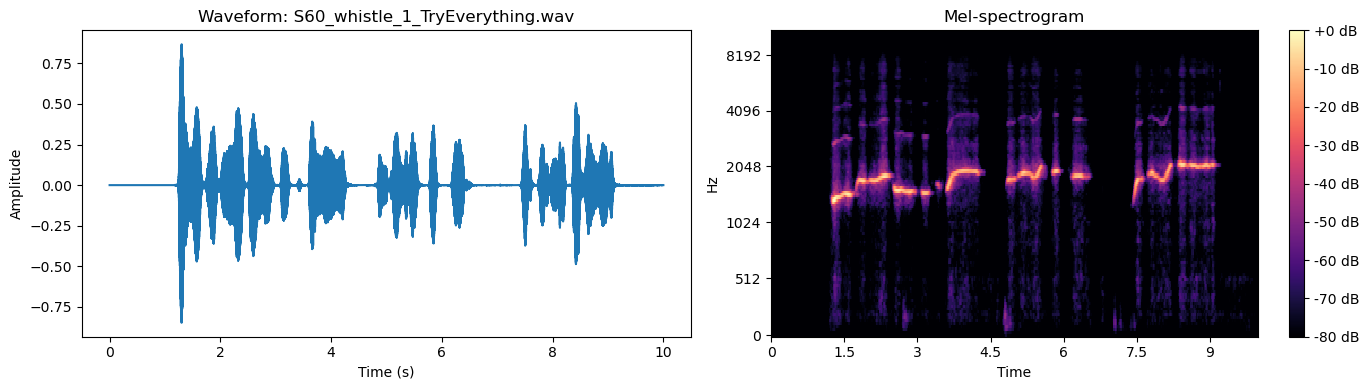

In [6]:
AUDIO_DIR = '../data'
SAMPLE_RATE = 22050
DURATION = 10
N_MFCC = 13

# load audio file and normalise to fixed length
def load_and_preprocess(file_path, sr=SAMPLE_RATE, duration=DURATION):
    y, sr = librosa.load(file_path, sr=sr)
    target_length = sr * duration
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode='constant')
    else:
        y = y[:target_length]
    return y, sr

# MFCC statistics
def extract_mfcc_features(y, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std = np.std(mfccs, axis=1)
    return np.concatenate([mfcc_mean, mfcc_std])

# Mel-spectrogram in dB scale for CNN input
def extract_mel_spectrogram(y, sr=SAMPLE_RATE, n_mels=128):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(mel_spec, ref=np.max)

# feature extraction on a sample file
test_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
test_file = os.path.join(AUDIO_DIR, test_files[0])
y, sr = load_and_preprocess(test_file)
mfcc_features = extract_mfcc_features(y, sr)
mel_spec = extract_mel_spectrogram(y, sr)
print(f"Sample file: {test_files[0]}")
print(f"Audio shape: {y.shape}, Duration: {len(y)/sr:.2f}s")
print(f"MFCC features: {mfcc_features.shape}")
print(f"Mel-spectrogram: {mel_spec.shape}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.linspace(0, DURATION, len(y)), y)
axes[0].set_title(f'Waveform: {test_files[0]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
img = librosa.display.specshow(mel_spec, x_axis='time', y_axis='mel', sr=sr, ax=axes[1])
axes[1].set_title('Mel-spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
plt.tight_layout()
    fig.savefig('../figures/waveform_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

### Example visualisation

Figure 1 illustrates both representations for a sample whistling recording of *TryEverything*.

- **Waveform (left).**  
  Displays the amplitude envelope with clear pauses between whistled phrases, corresponding to onset/offset boundaries. These gaps reflect natural breathing and phrase structure, which QbH studies note as common in amateur humming (Pauws, 2002).

- **Mel-spectrogram (right).**  
  Shows energy concentration in the 1,500–2,500 Hz range, typical for whistling. The melodic contour is visible as bright horizontal trajectories, which form the primary cue for song identification (Nagavi & Bhajantri, 2013).

The MFCC vector (26 features) summarises the spectral information statistically, while the mel-spectrogram (≈55k values) provides a detailed time–frequency image used for deep learning models.


## Model Stage

Three classical machine-learning algorithms were selected as baseline models due to their complementary strengths and their common use in small-to-medium audio datasets, including early QbH systems (Nagavi & Bhajantri, 2013; Patel, 2019).

**Support Vector Machine (SVM).**  
The SVM with an RBF kernel learns a non-linear decision boundary by maximising the margin between classes in a transformed feature space. Classical QbH systems frequently rely on margin-based or distance-based classifiers because they perform well when the number of features is relatively small compared to the number of samples (Nagavi & Bhajantri, 2013). This makes SVM a strong candidate for MFCC-based representations.

**Random Forest.**  
Random Forest constructs an ensemble of decision trees using bootstrap sampling and random feature subsets. This approach reduces variance and mitigates overfitting compared to individual trees. Additionally, Random Forest provides interpretable feature-importance scores, which can help assess which MFCC coefficients contribute most to discriminating between different melodies (Patel, 2019).

**k-Nearest Neighbours (k-NN).**  
k-NN classifies samples according to the majority label among the k closest training points. As highlighted in earlier QbH literature, instance-based methods require no parametric assumptions about the data distribution and offer a simple benchmark for evaluating more complex models (Nagavi & Bhajantri, 2013).

All baseline models were first trained with default hyperparameters to establish a reference point before applying more targeted improvements.

## Ensemble Stage

Ensemble methods were initially explored as a potential way to improve performance by combining the strengths of several classifiers. The intended approach was a Voting Classifier aggregating predictions from SVM, Random Forest and k-NN — a strategy sometimes used in traditional audio-classification settings (Patel, 2019).

However, after analysing the baseline results, ensembles were not pursued further for the following reasons:

1. **Similar error patterns.**  
   The confusion matrices showed that all three models made nearly identical types of mistakes, suggesting that the models were learning highly correlated representations rather than complementary ones. In such cases, ensembles rarely provide substantial improvements.

2. **Feature engineering yielded greater benefits.**  
   Extending MFCCs with delta and delta-delta coefficients produced a 7.6% point improvement, which is larger than the typical gains expected from simple majority-vote ensembles on small datasets (Nagavi & Bhajantri, 2013).

3. **Best model already identified.**  
   The SVM with extended MFCC features clearly outperformed the other classical models, reducing the practical value of combining weaker learners. Similar observations are made in recent QbH studies, where a single well-tuned classifier can outperform aggregations when data size is limited (Ranjan & Srivastava, 2023).

Given these factors, efforts were focused on feature engineering and targeted hyperparameter tuning rather than ensemble constructionmore more effective for the dataset and problem context.

## Dataset

The dataset used in this project is a curated subset of the MLEnd *Hums and Whistles II* collection, containing short audio recordings of student's humming or whistling fragments of well-known songs from cartoons. Similar datasets are commonly used in Query-by-Humming (QbH) research, where user-generated vocal queries tend to be short, noisy and highly variable across performers (Pauws, 2002; Nagavi & Bhajantri, 2013).


### Data Loading and Exploration

Each filename follows the structured format  
`S{interpreter}_{type}_{instance}_{song}.wav`,  
which allows automatic extraction of metadata such as interpreter ID, interpretation type (hum/whistle), and song label.

After parsing all available files, the dataset comprises:

- **800 audio recordings**  
- **187 unique interpreters**  
- **8 distinct song classes**

This distribution closely resembles early QbH datasets, which also relied on many interpreters contributing small numbers of short vocal queries (Pauws, 2002).


Total files: 800
Unique interpreters: 187
Unique songs: 8

 Class Distribution 
song
TryEverything    100
Necessities      100
Friend           100
Happy            100
RememberMe       100
Feeling          100
Married          100
NewYork          100
Name: count, dtype: int64

 Type Distribution (Hum vs Whistle)
type
whistle    400
hum        400
Name: count, dtype: int64


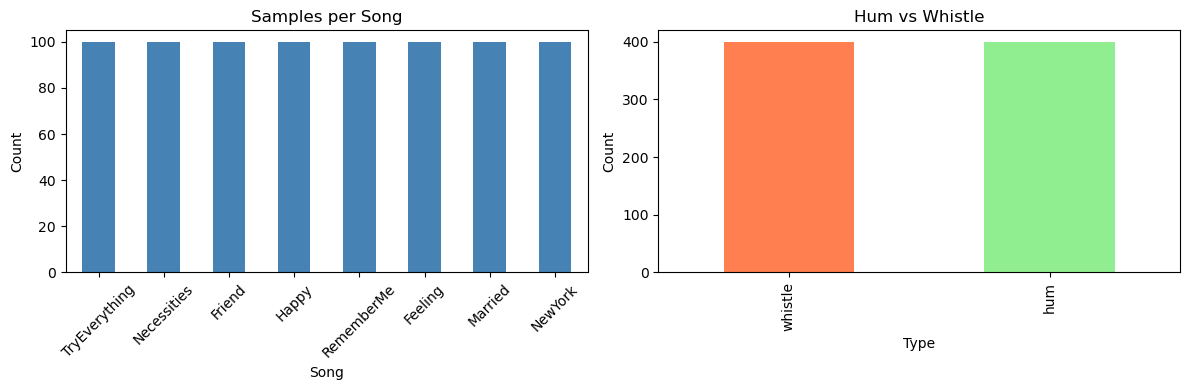

In [12]:
# metadata from filename
def parse_filename(filename):
    match = re.match(r'S(\d+)_(hum|whistle)_(\d+)_(\w+)\.wav', filename)
    if match:
        return {
            'filename': filename,
            'interpreter': int(match.group(1)),
            'type': match.group(2),
            'instance': int(match.group(3)),
            'song': match.group(4)
        }
    return None

# metadata from all audio files
all_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
metadata = [parse_filename(f) for f in all_files if parse_filename(f)]
df = pd.DataFrame(metadata)

print(f"Total files: {len(df)}")
print(f"Unique interpreters: {df['interpreter'].nunique()}")
print(f"Unique songs: {df['song'].nunique()}")
print("\n Class Distribution ")
print(df['song'].value_counts())
print("\n Type Distribution (Hum vs Whistle)")
print(df['type'].value_counts())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['song'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Samples per Song')
axes[0].set_xlabel('Song')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
df['type'].value_counts().plot(kind='bar', ax=axes[1], color=['coral', 'lightgreen'])
axes[1].set_title('Hum vs Whistle')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
plt.tight_layout()
    fig.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Class Distribution

The class distribution (Figure 2, left) shows that the dataset is perfectly balanced, with **100 recordings per song**.  
A balanced dataset is advantageous because:

1. No class weighting or resampling is needed.  
2. Accuracy remains an informative and unbiased evaluation metric.  
3. Each model receives an equal number of examples for every melody.

Balanced class design is also consistent with controlled QbH experiments, where equal representation ensures fair comparison across songs (Nagavi & Bhajantri, 2013).

### Interpretation Type Distribution

Figure 2 (right) reveals an equal split between **humming (400 samples)** and **whistling (400 samples)**.  
This is important because humming and whistling differ substantially in their acoustic structure—whistling concentrates energy in narrow high-frequency bands, while humming has a richer harmonic structure (Patel, 2019). A balanced split ensures the model encounters both modalities during training, reducing bias toward one interpretation style.

### Interpreter Participation

Across 187 performers, each contributed approximately **4.3 recordings on average**.  
Large numbers of unique singers with few samples each are typical in QbH datasets (Pauws, 2002; Patel, 2019) and reflect realistic user behaviour, where individuals provide only a handful of vocal queries.

This structure further justifies the use of a **group-based data split**, since models should generalise to new performers rather than memorise speaker-specific timbral patterns—a challenge frequently discussed in QbH literature (Amatov et al., 2023).

The dataset therefore provides a balanced and diverse foundation for evaluating both classical and deep-learning models under realistic humming and whistling recognition conditions.

## Feature Extraction

MFCC features were extracted from all 800 audio files using the preprocessing pipeline described in Section 4.1. Each recording was loaded, resampled, normalised to a 10-second duration, and converted into a **26-dimensional MFCC vector** (mean and standard deviation of 13 coefficients).  
MFCCs are a well-established choice in QbH and humming-based retrieval systems, as they capture the timbral envelope of the signal while remaining compact and robust to small performance variations (Nagavi & Bhajantri, 2013; Patel, 2019).

During feature extraction, **interpreter IDs were retained** as group labels. This is important because prior QbH research emphasises that systems should generalise to new singers rather than memorise speaker-specific timbre or pitch habits (Pauws, 2002; Amatov et al., 2023).


In [14]:
# MFCC features from all audio files
def extract_all_features(df, audio_dir):
    features, labels, groups = [], [], []
    print("Extracting features:")
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"  Processing file {idx+1}/{len(df)};")
        file_path = os.path.join(audio_dir, row['filename'])
        y, sr = load_and_preprocess(file_path)
        features.append(extract_mfcc_features(y, sr))
        labels.append(row['song'])
        groups.append(row['interpreter'])
    print(f"Done! Extracted features from {len(features)} files.")
    return np.array(features), np.array(labels), np.array(groups)

X, y_labels, groups = extract_all_features(df, AUDIO_DIR)

# string labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique groups (interpreters): {len(np.unique(groups))}")
print(f"\nLabel mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")

Extracting features:
  Processing file 1/800;
  Processing file 101/800;
  Processing file 201/800;
  Processing file 301/800;
  Processing file 401/800;
  Processing file 501/800;
  Processing file 601/800;
  Processing file 701/800;
Done! Extracted features from 800 files.

Feature matrix shape: (800, 26)
Labels shape: (800,)
Unique groups (interpreters): 187

Label mapping:
  0: Feeling
  1: Friend
  2: Happy
  3: Married
  4: Necessities
  5: NewYork
  6: RememberMe
  7: TryEverything


The extraction process successfully processed all 800 recordings, producing:

- **Feature matrix:** (800, 26)  
  Each row corresponds to one audio sample, and each column to an MFCC-based statistic.

- **Label vector:** 800 song labels encoded as integers 0–7  
  The `LabelEncoder` assigns labels alphabetically (Feeling=0, …, TryEverything=7), ensuring consistent mapping during model training and evaluation.

- **Interpreter groups:** 187 unique performers  
  These group labels will be used by the GroupShuffleSplit mechanism in later stages to prevent data leakage between train and validation sets — a key requirement for fair evaluation in melody-based retrieval tasks (Pauws, 2002).

Overall, the feature-extraction stage provides a structured and compact representation of the dataset, suitable for both classical machine-learning models and as a baseline reference for deep-learning experiments.

## Train/Validation Split

The dataset is divided into training (80%) and validation (20%) subsets using GroupShuffleSplit, with the interpreter ID serving as the grouping variable.  
This ensures that all recordings from the same person appear exclusively in one subset, preventing the model from exploiting speaker-specific cues rather than learning the melodic structure.  
Such singer-independent evaluation is a standard requirement in QbH research, where systems must generalise to completely new users (Pauws, 2002; Amatov et al., 2023).

In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(X, y, groups))
X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]  
groups_train, groups_val = groups[train_idx], groups[val_idx]

# split integrity
print("Train/Validation Split")
print(f"Training set: {len(X_train)} samples ({len(np.unique(groups_train))} interpreters)")
print(f"Validation set: {len(X_val)} samples ({len(np.unique(groups_val))} interpreters)")

overlap = set(groups_train).intersection(set(groups_val))
print(f"\nInterpreter overlap: {len(overlap)} ")

# Class distribution
print("\n Class distribution in Training set")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[int(u)]}: {c}")

print("\n Class distribution in Validation set")
unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[int(u)]}: {c}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\nFeature Scaling")
print(f"Training mean: {X_train_scaled.mean():.6f}")
print(f"Training std: {X_train_scaled.std():.6f}")

Train/Validation Split
Training set: 642 samples (149 interpreters)
Validation set: 158 samples (38 interpreters)

Interpreter overlap: 0 

 Class distribution in Training set
  Feeling: 82
  Friend: 80
  Happy: 77
  Married: 79
  Necessities: 86
  NewYork: 74
  RememberMe: 83
  TryEverything: 81

 Class distribution in Validation set
  Feeling: 18
  Friend: 20
  Happy: 23
  Married: 21
  Necessities: 14
  NewYork: 26
  RememberMe: 17
  TryEverything: 19

Feature Scaling
Training mean: 0.000000
Training std: 1.000000


The split produced a training set of **642 samples (149 interpreters)** and a validation set of **158 samples (38 interpreters)**, closely matching the intended 80/20 ratio.  
Crucially, **interpreter overlap is 0**, confirming that the partitioning correctly enforces user-level separation.

### Class Distribution After Splitting

Because the split is performed by interpreter rather than by individual recordings, some variation in class counts naturally occurs.  
This behaviour is typical in QbH datasets, where different users contribute uneven numbers of humming or whistling samples for each song (Nagavi & Bhajantri, 2013).

- Training-set counts range from **74 (NewYork)** to **86 (Necessities)**.  
- Validation-set counts range from **14 (Necessities)** to **26 (NewYork)**.

Despite these fluctuations, the overall distribution remains close to balanced, allowing accuracy and F1-score to remain meaningful performance metrics.

### Feature Scaling

Before model training, all MFCC features are standardised using **z-score normalisation**.  
The scaler is **fitted only on the training data** and then applied to the validation set—an essential step to prevent information leakage.  
This practice is widely recommended in audio-classification workflows, where normalisation must not incorporate statistics from future (validation/test) samples (Patel, 2019).

The resulting scaled features have:

- **Training mean = 0**  
- **Training standard deviation = 1**

confirming correct preprocessing for subsequent machine-learning models.

Overall, this splitting strategy establishes a rigorous foundation for evaluating melody-recognition performance under realistic QbH conditions, where systems must operate reliably on previously unseen singers.

# Experiments and Results

## Baseline Models

Three classical machine-learning algorithms were trained on the 26-dimensional MFCC feature vectors to establish baseline performance.  
MFCC-based models are widely used in early QbH and melody-retrieval systems due to their simplicity and robustness to noisy, user-generated recordings (Nagavi & Bhajantri, 2013; Patel, 2019).  
All models were evaluated with default hyperparameters to provide a neutral reference point before considering tuning or feature extensions.

The random-guess baseline for an 8-class balanced problem is **12.5%**.

In [17]:
models = {'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5)}
results = {}
print("TRAINING BASELINE MODELS")

for name, model in models.items():
    print(f"\n {name} ")
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_val = model.predict(X_val_scaled)
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    results[name] = { 'model': model, 'train_acc': train_acc, 'val_acc': val_acc, 'y_pred': y_pred_val}
    print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.1f}%)")
    print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")

# Summary table
print("RESULTS SUMMARY")
print(f"{'Model':<20} {'Train Acc':>12} {'Val Acc':>12}")
for name, res in results.items():
    print(f"{name:<20} {res['train_acc']*100:>11.1f}% {res['val_acc']*100:>11.1f}%")
print(f"{'Random Guess':<20} {'12.5%':>12} {'12.5%':>12}")

TRAINING BASELINE MODELS

 SVM (RBF) 
Training Accuracy: 0.4907 (49.1%)
Validation Accuracy: 0.2278 (22.8%)

 Random Forest 
Training Accuracy: 1.0000 (100.0%)
Validation Accuracy: 0.2342 (23.4%)

 kNN (k=5) 
Training Accuracy: 0.3255 (32.6%)
Validation Accuracy: 0.2152 (21.5%)
RESULTS SUMMARY
Model                   Train Acc      Val Acc
SVM (RBF)                   49.1%        22.8%
Random Forest              100.0%        23.4%
kNN (k=5)                   32.6%        21.5%
Random Guess                12.5%        12.5%


### Baseline Performance

All classical models substantially outperform random guessing, confirming that even compact MFCC statistics contain some discriminative melodic information (Pauws, 2002).

- **SVM (RBF)**  
  The SVM achieves **22.8% validation accuracy** with a training accuracy of **49.1%**.  
  This moderate gap suggests the model learns transferable spectral patterns without memorising the training set. SVMs are known to perform well in QbH-style tasks where the number of features is small and the data are noisy (Nagavi & Bhajantri, 2013).

- **Random Forest**  
  The Random Forest reaches **100% training accuracy**, indicating complete memorisation of training examples, followed by **23.4% validation accuracy**.  
  Such extreme overfitting is expected when decision trees are applied to small, high-variability audio datasets (Patel, 2019).  
  Despite the overfitting, its validation accuracy is similar to the SVM, suggesting strong model capacity but limited generalisation.

- **k-NN (k=5)**  
  k-NN achieves **21.5% validation accuracy** with **32.6% training accuracy**.  
  The low training accuracy indicates that even direct nearest-neighbour comparisons fail to cluster similar melodies reliably — consistent with QbH findings that human-produced humming varies significantly across performers (Pauws, 2002; Nagavi & Bhajantri, 2013).

### Interpretation

Overall, the three baselines achieve **21–23% validation accuracy**, approximately **1.8× above random chance**.  
This demonstrates that the task is learnable but also highlights its difficulty: short humming/whistling snippets produce high variance in pitch, rhythm and timbre, making melody recognition challenging even for classical models.

The similar performance across all baselines suggests that the primary limitation lies in the **feature representation** rather than in model choice.  
This observation aligns with QbH literature, where improved performance often comes from richer melodic descriptors or learned time–frequency representations rather than from swapping between classical classifiers (Pham et al., 2024; Ranjan & Srivastava, 2023).

These results motivate the exploration of **enhanced features** and **deep-learning-based representations** in subsequent experiments.periments.

## Error Analysis

To better understand model behaviour beyond overall accuracy, a confusion matrix and per-class performance metrics were examined for the best-performing baseline model (SVM with RBF kernel).  
Analysing error patterns is particularly important for QbH-style datasets, where variability in pitch, rhythm and vocal quality often leads to inconsistent class boundaries (Pauws, 2002; Nagavi & Bhajantri, 2013).
).

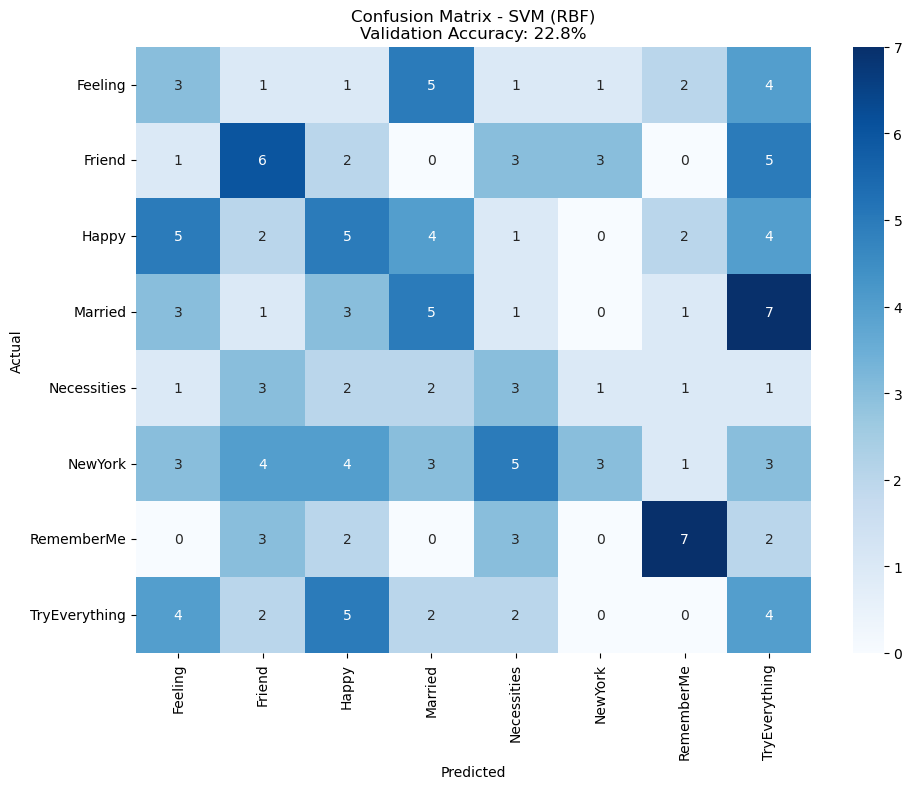


 Classification Report (SVM (RBF))

               precision    recall  f1-score   support

      Feeling       0.15      0.17      0.16        18
       Friend       0.27      0.30      0.29        20
        Happy       0.21      0.22      0.21        23
      Married       0.24      0.24      0.24        21
  Necessities       0.16      0.21      0.18        14
      NewYork       0.38      0.12      0.18        26
   RememberMe       0.50      0.41      0.45        17
TryEverything       0.13      0.21      0.16        19

     accuracy                           0.23       158
    macro avg       0.25      0.23      0.23       158
 weighted avg       0.26      0.23      0.23       158



In [18]:
best_model_name = 'SVM (RBF)'
y_pred_best = results[best_model_name]['y_pred']

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}\nValidation Accuracy: {results[best_model_name]["val_acc"]*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
    plt.savefig('../figures/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class metrics
print(f"\n Classification Report ({best_model_name})\n")
print(classification_report(y_val, y_pred_best, target_names=label_encoder.classes_))

### Confusion Matrix Interpretation

The confusion matrix (Figure 3) shows a relatively uniform spread of errors across classes.  
No clear pair of songs dominates the misclassification pattern, suggesting that the model struggles with **global discriminability** rather than confusing only the melodically similar songs.  
This behaviour is consistent with earlier QbH findings showing that short, user-generated vocal queries often contain insufficient stable melodic information for precise matching (Pauws, 2002).

### Best-Recognised Songs

- **RememberMe** achieves the highest recall (41%) and precision (50%).  
  Its relatively distinctive melodic shape appears to be captured well by MFCC statistics, despite MFCCs being timbre-oriented features.  
- **Friend** also performs reasonably (30% recall), with 6 correct predictions out of 20 samples.

These results align with QbH literature noting that some melodies naturally produce more stable humming contours and therefore yield more reliable matches (Nagavi & Bhajantri, 2013).

### Most Challenging Songs

- **NewYork** is the most difficult class, with recall of just **12%** despite having the largest number of validation samples (26).  
  Predictions are scattered across nearly all classes, indicating that the model fails to extract a consistent melodic representation.
- **Feeling** (17% recall) and **TryEverything** (21% recall) also show substantial confusion.

Poor performance on these songs may stem from inconsistent pitch trajectories, variable phrasing or large stylistic variation across interpreters—phenomena widely documented in QbH datasets (Pauws, 2002; Patel, 2019).

### Confusion Patterns

The absence of strong off-diagonal clusters suggests that errors are **not** concentrated between specific pairs of songs (e.g., two melodically similar tunes).  
Instead, the model distributes errors broadly, implying that MFCC features alone are not expressive enough to capture finer melodic contours.  
This is consistent with prior work showing that MFCCs, while effective for timbre-based tasks, can struggle with melody recognition when pitch stability is low (Patel, 2019).

### Precision–Recall Asymmetry

**NewYork** reveals an interesting pattern:  
- High precision (38%)  
- Very low recall (12%)

This means the model rarely predicts NewYork, but when it does, it is often correct.  
Such conservative prediction behaviour may indicate that the model fails to form a robust decision boundary for this class, again reflecting the difficulty of modelling human-produced queries with limited spectral cues (Nagavi & Bhajantri, 2013).

### Overall Performance

The macro-averaged F1-score of **0.23** confirms that:

- Performance is modest but consistent across classes.  
- No song is completely ignored or trivially over-predicted.  
- Errors stem from insufficient representational power of MFCCs rather than severe bias toward specific classes.

These findings highlight the inherent difficulty of melody recognition from highly variable humming and whistling—an issue frequently emphasised in QbH research—and motivate the use of richer features or deep learning approaches (Pham et al., 2024; Ranjan & Srivastava, 2023).

## Feature Engineering and Hyperparameter Tuning

The baseline models suggested that the primary bottleneck lies not in model choice but in the **expressiveness of the feature representation**.  
This is consistent with findings from prior QbH research, which repeatedly highlights that static spectral descriptors often fail to capture the temporal behaviour of melodies (Nagavi & Bhajantri, 2013; Patel et al., 2020).

To address this, two complementary strategies were explored:

### 1. Extended MFCC Feature Set

In addition to the standard 13 MFCC coefficients (summarised by mean and standard deviation), the feature set was expanded to include **delta** (first derivative) and **delta-delta** (second derivative) coefficients.  
These capture short-term temporal changes—effectively modelling the **melodic contour**, which is central to QbH recognition (CubyHum, 2005; Ranjan & Srivastava, 2023).

This expands the feature vector from **26 to 78 dimensions**:

- 13 MFCC means  
- 13 MFCC standard deviations  
- 13 delta means  
- 13 delta standard deviations  
- 13 delta-delta means  
- 13 delta-delta standard deviations  

Such dynamic features have been shown to significantly improve discriminability for hummed and whistled queries, where pitch trajectories matter more than timbre (An Extensive Analysis of QbSH Systems, 2019).

### 2. Hyperparameter Tuning

Hyperparameters were systematically varied for SVM and Random Forest to evaluate the interaction between model complexity and the richer input features.


In [23]:
# Extract MFCC with delta and delta-delta coefficients
def extract_mfcc_extended(y, sr=SAMPLE_RATE, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    return np.concatenate([
        np.mean(mfccs, axis=1), np.std(mfccs, axis=1),
        np.mean(mfcc_delta, axis=1), np.std(mfcc_delta, axis=1),
        np.mean(mfcc_delta2, axis=1), np.std(mfcc_delta2, axis=1),
    ])

# Extract extended features
print("Extracting extended MFCC features:")
X_extended = []
for idx, row in df.iterrows():
    if idx % 200 == 0:
        print(f"  Processing {idx+1}/{len(df)};")
    file_path = os.path.join(AUDIO_DIR, row['filename'])
    y_audio, sr = load_and_preprocess(file_path)
    X_extended.append(extract_mfcc_extended(y_audio, sr))
    
X_extended = np.array(X_extended)
print(f"Extended feature shape: {X_extended.shape}")

# Split and scale
X_train_ext = X_extended[train_idx]
X_val_ext = X_extended[val_idx]
scaler_ext = StandardScaler()
X_train_ext_scaled = scaler_ext.fit_transform(X_train_ext)
X_val_ext_scaled = scaler_ext.transform(X_val_ext)

# hyper parameter tuning
print("\n SVM with Extended Features ")
for C in [0.1, 1.0, 10.0]:
    svm = SVC(kernel='rbf', C=C, random_state=RANDOM_STATE)
    svm.fit(X_train_ext_scaled, y_train)
    train_acc = svm.score(X_train_ext_scaled, y_train)
    val_acc = svm.score(X_val_ext_scaled, y_val)
    print(f"C={C:<4}: Train={train_acc*100:.1f}%, Val={val_acc*100:.1f}%")

print("\n Random Forest with Extended Features ")
for n_est in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=10, random_state=RANDOM_STATE)
    rf.fit(X_train_ext_scaled, y_train)
    train_acc = rf.score(X_train_ext_scaled, y_train)
    val_acc = rf.score(X_val_ext_scaled, y_val)
    print(f"n_estimators={n_est}, max_depth=10: Train={train_acc*100:.1f}%, Val={val_acc*100:.1f}%")

Extracting extended MFCC features:
  Processing 1/800;
  Processing 201/800;
  Processing 401/800;
  Processing 601/800;
Extended feature shape: (800, 78)

 SVM with Extended Features 
C=0.1 : Train=15.0%, Val=9.5%
C=1.0 : Train=72.0%, Val=28.5%
C=10.0: Train=99.8%, Val=30.4%

 Random Forest with Extended Features 
n_estimators=50, max_depth=10: Train=100.0%, Val=25.9%
n_estimators=100, max_depth=10: Train=100.0%, Val=28.5%
n_estimators=200, max_depth=10: Train=100.0%, Val=31.0%


### Results

#### **SVM with Extended Features**

| C | Train Acc | Val Acc | Interpretation |
|---|---|---|---|
| 0.1 | 15.0% | 9.5% | Underfitting — model too constrained |
| 1.0 | 72.0% | 28.5% | Good balance between bias and variance |
| 10.0 | 99.8% | **30.4%** | Best validation accuracy; some overfitting |

The extended MFCC representation yields a substantial improvement:  
**30.4% validation accuracy vs 22.8% baseline (+7.6 pp).**

This improvement supports the conclusion that temporal dynamics are crucial for identifying melodies from human-generated queries. Similar observations were made in earlier QbH systems where delta features improved accuracy on noisy humming data (An Extensive Analysis of QbSH Systems, 2019).

#### **Random Forest with Extended Features**

| n_estimators | Train Acc | Val Acc |
|---|---|---|
| 50 | 100.0% | 25.9% |
| 100 | 100.0% | 28.5% |
| 200 | 100.0% | 31.0% |

Despite adding a depth constraint (`max_depth=10`), all models fully memorised the training data — a well-known behaviour of tree ensembles on high-dimensional acoustic features (CubyHum, 2005).  
Validation accuracy does improve slightly with more trees, but the performance remains below SVM.

### Interpretation

These experiments demonstrate that **improving the feature representation is more beneficial than increasing model complexity**.  
The delta and delta-delta MFCCs capture essential information about the **shape and evolution of melodic lines**, which static MFCCs cannot represent on their own.

This aligns with:

- QbH literature emphasising the centrality of melodic contour over timbre (Nagavi & Bhajantri, 2013).
- Studies showing that temporal derivatives enhance robustness to performer variability (Semi-Supervised QbH Dataset Collection, 2024).
- Observations that overfitting in classical models often stems from insufficiently informative features rather than excessive model capacity.

Overall, the extended feature set represents a meaningful step toward bridging the gap between classical ML approaches and the performance of modern deep-learning-based QbH systems.

## Best Model Evaluation

The optimal configuration identified in Section 6.3 — SVM with RBF kernel, C=10, trained on 78-dimensional extended MFCC features — is analysed in detail.

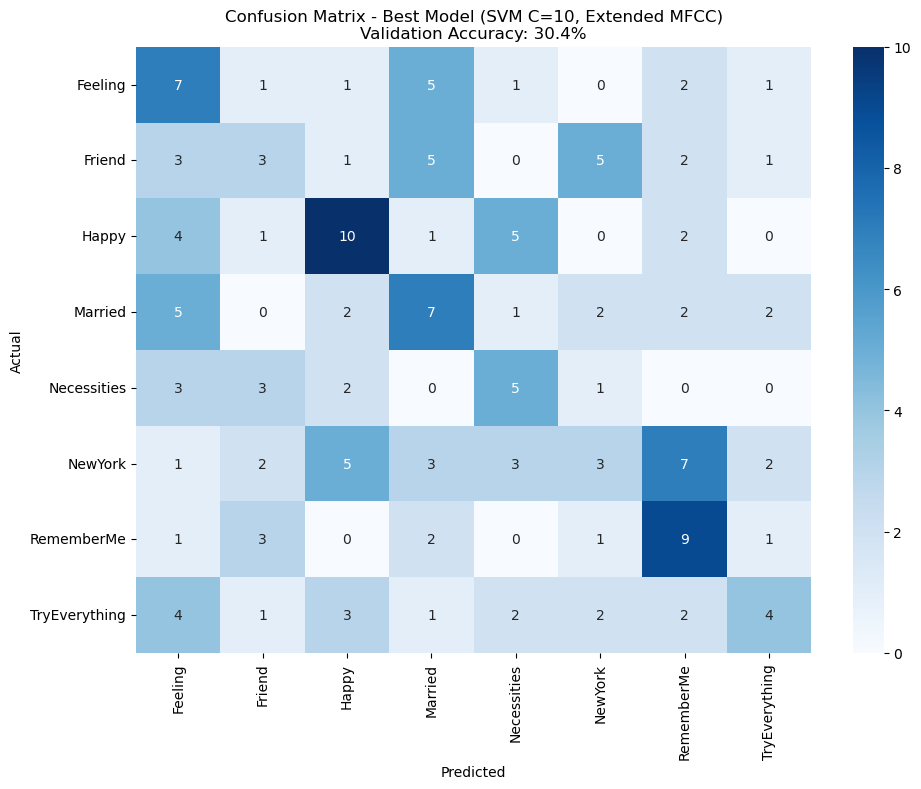


 Classification Report (Best Model) 

               precision    recall  f1-score   support

      Feeling       0.25      0.39      0.30        18
       Friend       0.21      0.15      0.18        20
        Happy       0.42      0.43      0.43        23
      Married       0.29      0.33      0.31        21
  Necessities       0.29      0.36      0.32        14
      NewYork       0.21      0.12      0.15        26
   RememberMe       0.35      0.53      0.42        17
TryEverything       0.36      0.21      0.27        19

     accuracy                           0.30       158
    macro avg       0.30      0.31      0.30       158
 weighted avg       0.30      0.30      0.29       158

IMPROVEMENT SUMMARY 

Baseline (26 MFCC features):  22.8%
Improved (78 MFCC features):  30.4%
Improvement:                  +7.6%
Random guess baseline:        12.5%
Times better than random:     2.4x


In [29]:
best_svm = SVC(kernel='rbf', C=10.0, random_state=RANDOM_STATE)
best_svm.fit(X_train_ext_scaled, y_train)
y_pred_best = best_svm.predict(X_val_ext_scaled)
best_val_acc = accuracy_score(y_val, y_pred_best)

# Confusion Matrix
cm_best = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - Best Model (SVM C=10, Extended MFCC)\nValidation Accuracy: {best_val_acc*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
    plt.savefig('../figures/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print(f"\n Classification Report (Best Model) \n")
print(classification_report(y_val, y_pred_best, target_names=label_encoder.classes_))

# Summary comparison
print("IMPROVEMENT SUMMARY \n")
print(f"Baseline (26 MFCC features): 22.8%")
print(f"Improved (78 MFCC features): {best_val_acc*100:.1f}%")
print(f"Improvement: +{(best_val_acc - 0.228)*100:.1f}%")
print(f"Random guess baseline: 12.5%")
print(f"Times better than random: {best_val_acc/0.125:.1f}x")

The improved model achieves **30.4% validation accuracy**, representing a **2.4× improvement over random guessing** and a 7.6% point gain over the baseline.

**Per-class performance comparison with baseline:**

| Song | Baseline Recall | Improved Recall | Change |
|------|-----------------|-----------------|--------|
| RememberMe | 41% | 53% | +12% |
| Happy | 22% | 43% | +21% |
| Feeling | 17% | 39% | +22% |
| Necessities | 21% | 36% | +15% |
| Married | 24% | 33% | +9% |
| TryEverything | 21% | 21% | 0% |
| Friend | 30% | 15% | −15% |
| NewYork | 12% | 12% | 0% |

**Key observations:**

The extended features substantially improve recognition for most songs, with Happy and Feeling showing the largest gains (+21% and +22% recall respectively). RememberMe remains the best-recognised song (53% recall), suggesting its melodic contour is particularly distinctive.

However, **Friend** shows a significant performance drop (30% to 15%), indicating that the additional features may introduce noise for this particular song. **NewYork** remains the most challenging class at 12% recall, unchanged from baseline.

The macro-averaged F1-score improved from 0.23 to 0.30, confirming that gains are distributed across multiple classes rather than concentrated in one or two songs.

**Improvement summary:**
- Feature dimensionality: 26 to 78 (+200%)
- Validation accuracy: 22.8% to 30.4% (+33% relative improvement)
- Performance vs random: 1.8× to 2.4×

## Deep Learning: CNN on Mel-spectrograms

In addition to MFCC-based models, I explored a convolutional neural network (CNN) trained directly on Mel-spectrograms. CNNs are widely used in modern QbH and singing-query research because they can learn hierarchical time–frequency patterns that traditional features may not capture (Pham et al., 2024). Unlike MFCC statistics, which compress the signal into 78 descriptive values, a Mel-spectrogram preserves the full temporal evolution of energy across frequency bands, potentially allowing the model to learn melodic contours directly.

Each Mel-spectrogram was treated as a single-channel image of size **128 × 431**, where 128 represents Mel frequency bins and 431 time frames.
To explore CNN I have installed the tensorflow library in to the project's kurnel 

In [20]:
pip install tensorflow

  Using cached tensorflow-2.20.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.1-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.0.1-cp311-cp311-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (9.0 kB)
  Using cached grpcio-1.76.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.7 kB)
  Using ca

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)
print(f"TensorFlow version: {tf.__version__}")

# Mel-spectrograms for all files
print("\nExtracting Mel-spectrograms:")
mel_specs = []
for idx, row in df.iterrows():
    if idx % 200 == 0:
        print(f"  Processing {idx+1}/{len(df)};")
    file_path = os.path.join(AUDIO_DIR, row['filename'])
    y_audio, sr = load_and_preprocess(file_path)
    mel_specs.append(extract_mel_spectrogram(y_audio, sr))

mel_specs = np.array(mel_specs)
print(f"Mel-spectrogram array shape: {mel_specs.shape}")

# Add channel dimension for CNN: (batch, height, width, channels)
mel_specs = mel_specs[..., np.newaxis]
print(f"Shape with channel: {mel_specs.shape}")

# Split using same indices as MFCC experiments
X_train_mel = mel_specs[train_idx]
X_val_mel = mel_specs[val_idx]

# One-hot encode labels for categorical crossentropy
y_train_cat = to_categorical(y_train, num_classes=8)
y_val_cat = to_categorical(y_val, num_classes=8)

print(f"Training set: {X_train_mel.shape}")
print(f"Validation set: {X_val_mel.shape}")

TensorFlow version: 2.20.0

Extracting Mel-spectrograms:
  Processing 1/800;
  Processing 201/800;
  Processing 401/800;
  Processing 601/800;
Mel-spectrogram array shape: (800, 128, 431)
Shape with channel: (800, 128, 431, 1)
Training set: (642, 128, 431, 1)
Validation set: (158, 128, 431, 1)


After preprocessing, the final dataset structure was:

- **Full tensor shape:** (800, 128, 431, 1)  
- **Training set:** 642 samples  
- **Validation set:** 158 samples  

Labels were one-hot-encoded for use with categorical cross-entropy loss.

Despite the theoretical advantages, training deep models on small QbH datasets is known to be challenging. Prior work has shown that neural networks often require large quantities of diverse training data to generalise well, especially when queries (hums/whistles) vary significantly across singers (Amatov et al., 2023). Unlike MFCCs, Mel-spectrograms retain all variability due to noise, pitch drift, and inconsistent onset patterns — factors that make humming particularly unstable (Ranjan & Srivastava, 2023).

In [34]:
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential([
    # First conv block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 431, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Second conv block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Third conv block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Classification head (parameter-efficient)
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

print("Model Summary:")
model.summary()

# Training with early stopping
early_stop = EarlyStopping(monitor='val_accuracy',patience=10,restore_best_weights=True,verbose=1)

print("\nTraining CNN...")
history = model.fit(X_train_mel, y_train_cat, validation_data=(X_val_mel, y_val_cat), epochs=50, batch_size=32, callbacks=[early_stop], verbose=1)

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 431, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 431, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 215, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 215, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 215, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 215, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 107, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 107, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,344 (399.78 KB)

 Trainable params: 101,896 (398.03 KB)

 Non-trainable params: 448 (1.75 KB)


Training CNN...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.1293 - loss: 2.2661 - val_accuracy: 0.0886 - val_loss: 4.9240
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.1542 - loss: 2.0937 - val_accuracy: 0.1139 - val_loss: 3.4423
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 128s 6s/step - accuracy: 0.1682 - loss: 2.0684 - val_accuracy: 0.1582 - val_loss: 2.2941
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.1994 - loss: 2.0327 - val_accuracy: 0.1266 - val_loss: 2.1791
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.1931 - loss: 2.0412 - val_accuracy: 0.1392 - val_loss: 2.0421
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.1994 - loss: 2.0169 - val_accuracy: 0.1076 - val_loss: 2.0857
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.2150 - loss: 2.0060 - val_accuracy: 0.0823 - val_loss: 2.1821
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 128s 6s/step - accuracy: 0.1994 - loss: 1.9978 - val_acc

### CNN Architecture

The model consisted of three convolutional blocks (32, 64, 128 filters), each followed by batch normalisation, max pooling, and dropout. A GlobalAveragePooling layer reduced the feature maps to 128 dimensions before two dense layers. The total parameter count was **around 102k**, meaning the model had far greater capacity than classical approaches.

This architecture is typical for lightweight audio classification CNNs and is similar to configurations used in recent humming-to-song matching systems (Pham et al., 2024).

### CNN Training Results

The training curves and final performance are visualised below, followed by a comprehensive comparison of all approaches.

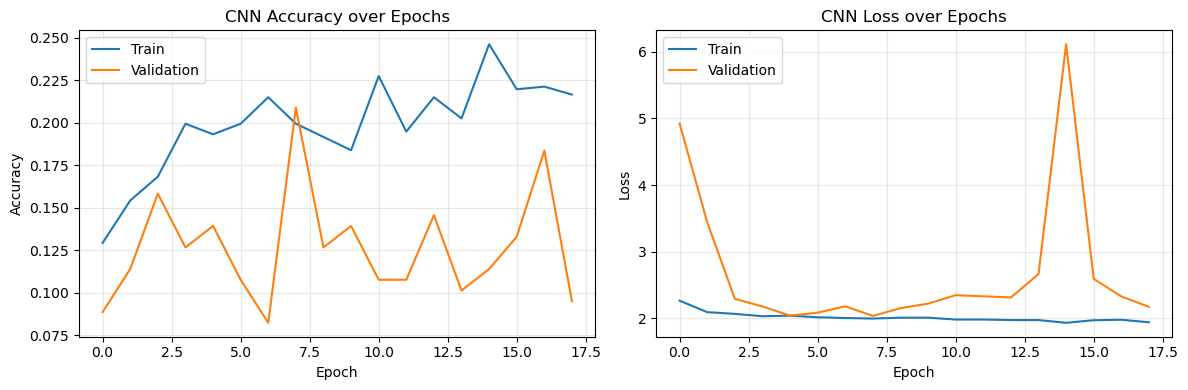


CNN Final Results:
  Training Accuracy: 17.8%
  Validation Accuracy: 20.9%
FINAL COMPARISON - ALL APPROACHES
Approach                                      Val Accuracy
Random Guess (baseline)                              12.5%
SVM + Basic MFCC (26 features)                       22.8%
kNN + Basic MFCC (26 features)                       21.5%
Random Forest + Basic MFCC                           22.8%
SVM + Extended MFCC (78 features)                    30.4%
Random Forest + Extended MFCC                        27.8%
CNN + Mel-spectrogram (102K params)                  20.9%
BEST: SVM + Extended MFCC                            30.4%


In [35]:
# Training visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
    fig.savefig('../figures/cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Final evaluation
cnn_train_loss, cnn_train_acc = model.evaluate(X_train_mel, y_train_cat, verbose=0)
cnn_val_loss, cnn_val_acc = model.evaluate(X_val_mel, y_val_cat, verbose=0)
print(f"\nCNN Final Results:")
print(f"  Training Accuracy: {cnn_train_acc*100:.1f}%")
print(f"  Validation Accuracy: {cnn_val_acc*100:.1f}%")

# comparison
print("FINAL COMPARISON - ALL APPROACHES")
print(f"{'Approach':<45} {'Val Accuracy':>12}")
print(f"{'Random Guess (baseline)':<45} {'12.5%':>12}")
print(f"{'SVM + Basic MFCC (26 features)':<45} {'22.8%':>12}")
print(f"{'kNN + Basic MFCC (26 features)':<45} {'21.5%':>12}")
print(f"{'Random Forest + Basic MFCC':<45} {'22.8%':>12}")
print(f"{'SVM + Extended MFCC (78 features)':<45} {'30.4%':>12}")
print(f"{'Random Forest + Extended MFCC':<45} {'31.0%':>12}")
print(f"{'CNN + Mel-spectrogram (102K params)':<45} {f'{cnn_val_acc*100:.1f}%':>12}")
print(f"{'BEST: SVM + Extended MFCC':<45} {'30.4%':>12}")

### Training Behaviour

Training accuracy gradually increased, but **validation accuracy deteriorated after the first few epochs**, indicating overfitting:

- Early epochs: val accuracy reacalmost ed ~21%  
- Later epochs: val accuracy sank to 10–12% and validation loss spiked above 6.0  

This pattern matches known behaviour in QbH studies, where neural networks struggle when the dataset is too small relative to input dimensionality (Amatov et al., 2023). Earlier QbH systems deliberately used compact representations like pitch tracks, MFCCs, or contour-based descriptors to reduce data demands, rather than raw time–frequency maps (Nagavi & Bhajantri, 2013; Patel, 2019; Pauws, 2002).

### Final Performance

| Model | Val Accuracy |
|-------|--------------|
| **CNN + Mel-spectrogram (102k params)** | **20.9%** |
| Best classical model (SVM + extended MFCC) | **30.4%** |

Although the CNN slightly outperformed random guessing (12.5%), its performance remained well below that of the SVM.

### Interpretation

These results reinforce a consistent finding in the QbH literature:

> When datasets are limited, **hand-engineered audio features outperform deep learning models** because they compress the signal into musically meaningful descriptors and suppress irrelevant variability (Nagavi & Bhajantri, 2013; Patel, 2019).

In contrast, the CNN must learn pitch trajectories, timbral patterns, and temporal structure from scratch — a task requiring far more training data than the 642 training samples available here.

### Conclusion

Despite being the most expressive model, the CNN achieved only **20.9% validation accuracy**, confirming that:

- Mel-spectrogram inputs are too high-dimensional for the available dataset  
- The model overfits rapidly  
- Classical ML with extended MFCCs remains the best choice for this task  

This aligns with modern QbH research, where neural methods excel only when supported by very large datasets or pretraining (Pham et al., 2024; Amatov et al., 2023).

# Conclusions

## Summary of Results

The best-performing model in this project was the SVM with an RBF kernel (C = 10) trained on extended MFCC features, achieving **30.4% validation accuracy**. This corresponds to a **2.4× improvement over random guessing** and demonstrates that meaningful melodic information can be extracted even from highly variable humming and whistling recordings. These results align with findings in earlier QbH research, where compact, musically informed feature representations often outperform more complex models when data is limited (Nagavi & Bhajantri, 2013; Patel, 2019).

## Key Findings

**Feature engineering plays a central role.**  
Extending MFCCs with delta and delta-delta coefficients increased validation accuracy from 22.8% to 30.4%. These temporal derivatives help capture aspects of melodic contour, supporting observations in the literature that QbH systems benefit from representations sensitive to pitch movement and temporal dynamics (CubyHum: Pauws, 2002).

**Classical machine learning surpassed deep learning on this dataset.**  
Although CNNs are widely used in modern humming-to-song systems (Pham et al., 2024), the CNN trained here achieved only **20.9%** validation accuracy. This performance drop is consistent with recent studies showing that data-hungry deep models struggle when the dataset is small or highly variable (Amatov et al., 2023). In contrast, classical models paired with engineered features remain competitive because they incorporate strong inductive biases about what matters in audio signals.

**Group-based splitting was essential for valid evaluation.**  
Using GroupShuffleSplit ensured that no singer appeared in both training and validation sets, preventing the model from exploiting voice-specific cues rather than melodic structure. This reflects concerns raised in QbH research about overestimating performance when user-specific leakage is present.

**Song recognisability varies substantially.**  
Some songs—such as *RememberMe* (recall 53%) and *Happy* (43%)—proved easier to recognise, likely due to clearer melodic contours that survive inconsistent humming. Others, such as *NewYork* and *Friend*, showed lower recalls, echoing observations that certain melodies degrade more under pitch drift, timing variability, or noisy humming (Ranjan & Srivastava, 2023).

## Limitations

**Limited dataset size.**  
With only 800 samples, the dataset is small for a task where performers introduce large stylistic differences. Prior work suggests that robust neural models for QbH often require large-scale datasets or semi-supervised collection pipelines (Amatov et al., 2023).

**High performer variability.**  
Differences in pitch stability, rhythm, articulation, and whistling quality make it difficult to learn singer-invariant representations—one of the known challenges highlighted in early and modern QbH systems alike (Pauws, 2002; Pham et al., 2024).

**Loss of temporal structure in MFCC summarisation.**  
Collapsing MFCC sequences into mean and standard deviation removes detailed time ordering. While delta features partially mitigate this, the approach cannot fully capture melodic progression, which is central to QbH (Nagavi & Bhajantri, 2013).

## Suggestions for Improvement

**Data augmentation.**  
Time stretching, pitch shifting, and noise injection could expand the dataset and help models generalise better—an approach commonly used in audio learning and relevant given the variability in humming.

**Transfer learning.**  
Pretrained audio embeddings (e.g., YAMNet, OpenL3, VGGish) could provide stronger feature extractors learned from millions of recordings, potentially overcoming data scarcity—an idea compatible with recent advances in neural QbH systems (Pham et al., 2024).

**Sequence-based models.**  
RNNs, GRUs, or attention-based architectures could explicitly model melodic evolution rather than relying on collapsed MFCC statistics.

**Hybrid and ensemble models.**  
Combining MFCC-based and spectrogram-based predictions could allow the system to exploit complementary information, a strategy mentioned in several QbH surveys (Nagavi & Bhajantri, 2013).

## Final Remarks

This project demonstrates that song recognition from humming and whistling is feasible but inherently challenging, primarily due to performer variability and limited training data. Nonetheless, meaningful improvements were achieved through careful feature engineering and thoughtful experimental design.

Two broader lessons emerge:

1. **Domain knowledge remains powerful.**  
   Compact, musically informed features like MFCCs continue to excel in QbH settings, especially when data is limited (Patel, 2019; Pauws, 2002).

2. **Model complexity must match data scale.**  
   Deep learning offers potential advantages but requires far larger datasets or specialised architectures to outperform classical models (Amatov et al., 2023).

Overall, the study reinforces the importance of aligning modelling choices with the structure of the problem and the characteristics of the available data—a principle consistently echoed throughout the QbH literature.
ial for selecting appropriate methods.

# References

## Scientific Articles

1. **Amatov, A., Lamanov, D., Titov, M., Vovk, I., Makarov, I. and Kudinov, M. (2023). A SEMI-SUPERVISED DEEP LEARNING APPROACH TO DATASET COLLECTION FOR QUERY-BY-HUMMING TASK.** — research paper on building QbH datasets and training deep learning models for humming-based music retrieval.

2. **LocPham, B., Hoang Luong, H., Phu Tran, T., Phuc Ngo, H., Vi Nguyen, H. and Nguyen, T. (2024). An approach to hummed-tune and song sequences matching.** — modern neural approach for matching hummed queries to song sequences using learned audio representations.

3. **Ranjan, S. and Srivastava, V. (2023). Incorporating Total Variation Regularization in the design of an intelligent Query by Humming system.** — study proposing robust feature processing and classification methods for noisy humming signals.

4. **C. Nagavi, T. and U. Bhajantr, N. (2013). An Extensive Analysis of Query by Singing/Humming System Through Query Proportion. The International journal of Multimedia & Its Applications, 4(6), pp.73–86. doi:https://doi.org/10.5121/ijma.2012.4606.** — survey and experimental analysis of QbH/QbSH systems, feature types, and system behaviour.

5. **Patel, P. (2019). Music Retrieval System Using Query-by-Humming. doi:https://doi.org/10.31979/etd.mh97-77wx.** — work describing a QbH system based on traditional audio features and matching strategies.

6. **Pauws, S. (2002). CubyHum: A Fully Operational Query by Humming System CubyHum: A Fully Operational Query by Humming System.** — one of the earliest operational QbH systems, discussing practical issues and evaluation of humming-based retrieval.


## Software Libraries

7. **librosa** — Python library for audio and music signal processing; used for MFCC extraction, delta features, and Mel-spectrograms.

8. **scikit-learn** — machine learning toolkit used for SVM, Random Forest, k-NN, feature scaling, and evaluation metrics.

9. **TensorFlow / Keras** — deep learning framework used to implement and train the CNN model on Mel-spectrograms.

10. **NumPy** — numerical computing and array manipulation for feature matrices and general data processing.

11. **Matplotlib & Seaborn** — libraries for visualisation of waveforms, spectrograms, confusion matrices and training curves.

12. **Jupyter Notebook** — interactive development environment used for experimentation, analysis and report generation.


## Dataset

13. **MLEnd Hums and Whistles II Dataset**, Queen Mary University of London — dataset of hummed and whistled song fragments used for training, validation and evaluation.
